<a href="https://colab.research.google.com/github/br1hs/MetricTensor/blob/main/Simple_Problems_on_Poisson's_equation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Some Problems on Laplace equation
### With numeric aplication


### When studying physics one eventually encounters problems where the solution (specially if it envolves differential equaions) can't be expressed or solved analitically, so numeric methods and scientific computing comes became very necessary. The following problems were personally selected by me and they all appered on class, homework or internet and i found the very interesting


The Heat equation, as its name suggest describes the behavoir of the heat flow over a certain volume or domain $V$ at a time, say $t\in[0,\infty)$. As a typical phisical problem it can be showned that the rate of heat tha flows over this region $V$ a time $t$ is given by the following partial differential equation:

$\frac{\partial\Phi}{\partial t}=K\nabla^2\Phi $

In this notebook we will be solving this equation for some particular explamples. As you might expect, this equation can be solved numerically of analytically depending on how horrible the problem itsself turns out to be.


## Poisson's Equation

Thanks to the Maxwell equation we can find that given a certain charge density distribution on a volumen $V$ (at the vacum), the asociated potential is given by the following equation:

$\nabla^2\phi=-\frac{\rho}{\epsilon_0}$

**Let's consider the following problem.**

Suppose we have 2-dimentional squared conducting plate distribution ($\rho=0$), every side has length L, Give an expression for the electric potential $\phi(x,y)$

Suppose we have 2-dimentional rectangular conducting plate ($\rho=0$), one of the sides has leght $a$ an the other $b$ and we know that the potential satisfies the following conditions:

* $V(x,0)=V(0,y)=V(a,y)=0$
* $V(x,b)=\begin{cases} V_0 \frac{a}{3}≤x ≤\frac{2a}{3}\\ 0 \,\,other \end{cases}$

Find an expression for the electrostatic potential.

**Solution:** This problem can be solved analytically in a very clean way, the overall solution of this problem is:

$\phi(x,y)=\sum_{n=1}^\infty \frac{2V_0}{n\pi sinh(\frac{n\pi}{a}b ) }\left( cos(\frac{n\pi}{3})-cos(\frac{2n\pi}{3}) \right)sin(\frac{n\pi}{a}x)sinh(\frac{n\pi}{a}y)$

Very neat expression, I know...

So for this proble we are now going to do two things, first make a density plot for the potential to see how it behaves all across the plate, and second, solve this problem numerically, i,e. integrating and differentiating with some numerical method.

Lets go with the plot first :)


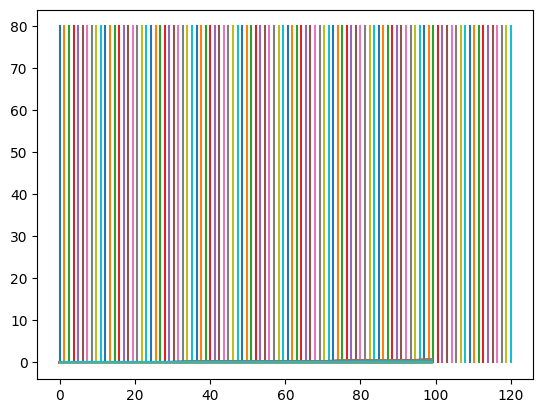

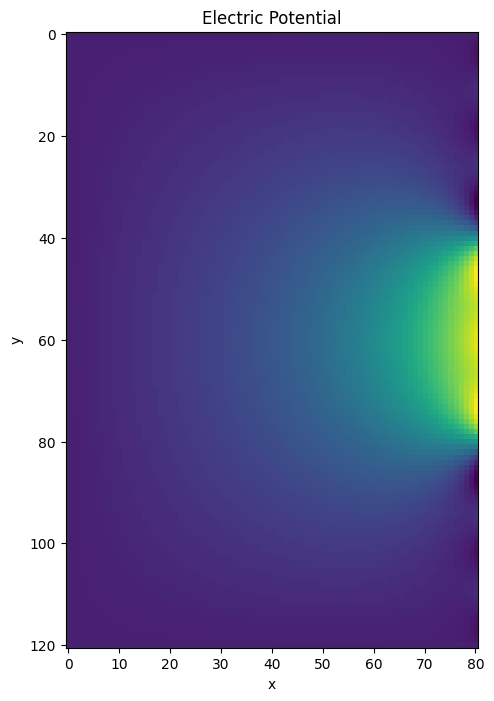

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from mpl_toolkits.mplot3d import Axes3D
import pylab as plb

#First we want to define the potential:

def phi_n(n,X,Y,V0,a,b):
  c_n=(2*V0/(n*np.pi*np.sinh(n*np.pi*b/a)))*(np.cos(n*np.pi/3)-np.cos(2*n*np.pi/3))

  return  c_n*np.sin(n*np.pi*X/a)*np.sinh(n*np.pi*Y/a)

a,b=120,80

X,Y=np.meshgrid(np.linspace(0,a,100),np.linspace(0,b,100))


plb.plot(X,Y,phi_n(1,X,Y,1,a,b))
plt.show()




PHI_n = np.zeros((a+1,b+1))

PHI=np.zeros((a+1,b+1))

Phi=[]
Phi=np.array(Phi)

N=15

for n in range(1,N+1):
  for i in range(a+1):  # recorremos todos los indices i de uno en uno (al aumentar el indice, nos movemos al siguiente punto x+h)
    for j in range(b+1):  # recorremos todos los indices j de uno en uno  (al aumentar el indice, nos movemos al siguiente punto y+h)

      PHI_n[i,j]=phi_n(n,i,j,1,a,b)


  PHI=PHI+PHI_n




fig, ax = plt.subplots(figsize=((12,8)))
plb.title('Electric Potential')
plb.xlabel('x')
plb.ylabel('y')

plb.imshow(PHI)


Now let's take a look to another problem. Consider an empty plate with conducting walls all conected to ground, but the top one with voltage $V$
Calculate the asociated potential numerically


For this problem we can use the **method of finite differencies**

As you can notice, the equation we want to solve now is simply:

$\nabla^2\phi=0$

So we can aproximate the laplacian as follows:

$\frac{\phi(x+h,y)+\phi(x-h,y)+\phi(x,y+h)+\phi(x,y-h)-4\phi(x,y) }{h^2}=0$

$\Longrightarrow \phi(x+h,y)+\phi(x-h,y)+\phi(x,y+h)+\phi(x,y-h)=4\phi(x,y)$

And thus:

$\phi(x,y)=\frac{1}{4}\left[\phi(x+h,y)+\phi(x-h,y)+\phi(x,y+h)+\phi(x,y-h) \right]$

This way we can consider the following:

$\phi_n(x,y)=\frac{1}{4}\left[\phi_{n-1}(x+h,y)+\phi_{n-1}(x-h,y)+\phi_{n-1}(x,y+h)+\phi_{n-1}(x,y-h) \right]$

Now, the last expression will give us a good aproximation of the potential, but you can easily notice that we need to know $\phi_0(x,y)$ to actually make this work. For that we will be using the **frontier conditions**, in this problem we have:

* $\phi(x,0)=\phi(0,y)=\phi(N,y)=0$
* $\phi(x,N)=V$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pylab as plb
import math


In [ ]:
# Programando las condiciones de frontera

V = 1.25
N = 10

PHI_n = np.zeros((N+1,N+1))
# PHI_n[:,N] = V
PHI_n[0,:] = V
PHI_n

array([[1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25, 1.25],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]])

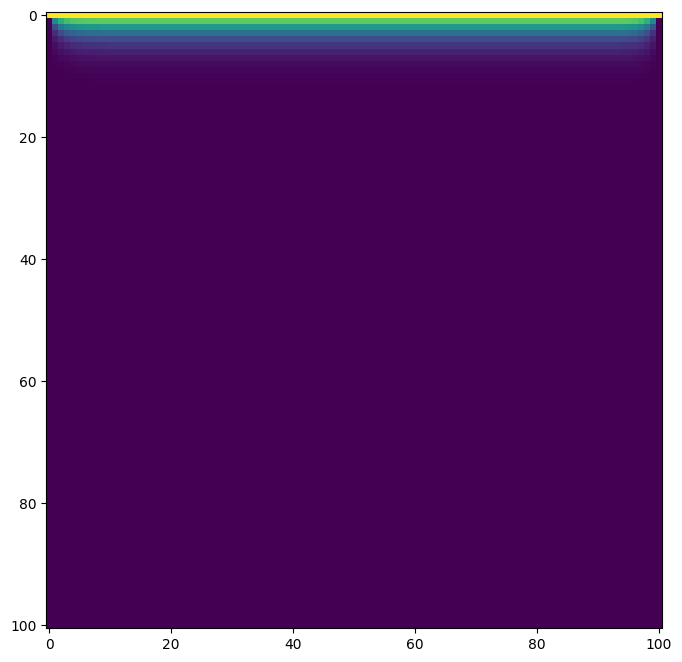

In [ ]:
V = 1.25
N = 100

PHI_n = np.zeros((N+1,N+1))
PHI_n[0,:] = V # condicion de frontera

for k in range(10): # lo hacemos k veces

    for i in range(N+1):  # recorremos todos los indices i de uno en uno (al aumentar el indice, nos movemos al siguiente punto x+h)
        for j in range(N+1):  # recorremos todos los indices j de uno en uno  (al aumentar el indice, nos movemos al siguiente punto y+h)

            if i == 0 or i == N or j == 0 or j == N: # fronteras
                PHI_n[i,j] = PHI_n[i,j] # aqui no cambia, pues son las condiciones de frontera
            else:
                PHI_n[i,j] = (PHI_n[i+1,j] + PHI_n[i-1,j] + PHI_n[i,j+1] + PHI_n[i,j-1])/4

fig, ax = plt.subplots(figsize=((12,8)))
plb.imshow(PHI_n)

Let's do another excercise but in this case we consider another frontier conditions.  

Say tha we have squared box of leght 1m and every single wall of it has cero potential, insider this box there are 2 squared boxes of with 20 cm in each side, one positively charged and the other is negative (see picture). Find the potential and make a density plot

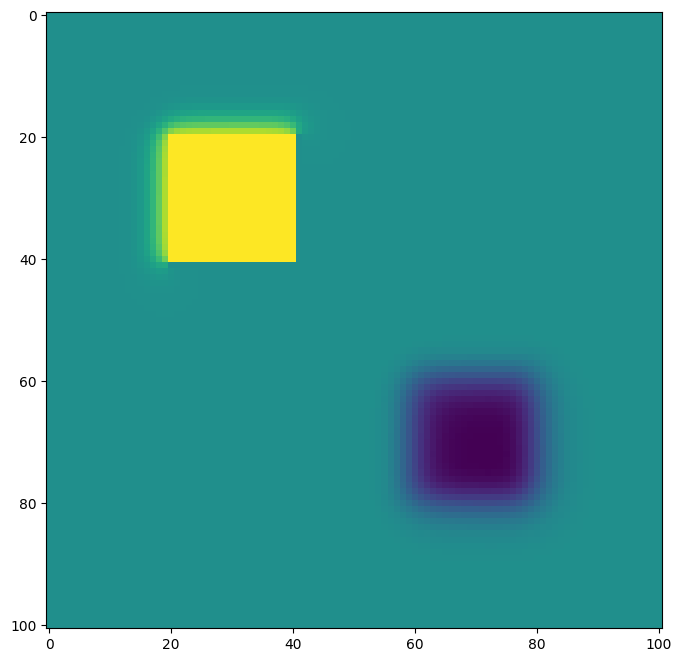

In [ ]:

N = 100

PHI_n = np.zeros((N+1,N+1))
PHI_n[20:41,20:41] = 1
PHI_n[60:81,60:81] = -1

for k in range(10): # lo hacemos k veces

    for i in range(N):  # recorremos todos los indices i de uno en uno (al aumentar el indice, nos movemos al siguiente punto x+h)
        for j in range(N):  # recorremos todos los indices j de uno en uno  (al aumentar el indice, nos movemos al siguiente punto y+h)

            if not (20<=i<=41 and 20<=j<=41) or (60<=i<=81 and 60<=i<=81):
                PHI_n[i,j] = (PHI_n[i+1,j] + PHI_n[i-1,j] + PHI_n[i,j+1] + PHI_n[i,j-1])/4

fig, ax = plt.subplots(figsize=((12,8)))
plb.imshow(PHI_n)

Consider now an spheric casquet of radius $R$, such that for a certain angle $\theta_0$, measured from the $z$ axis, the surface of this casquet has a connstan potential $V_0$, and the rest of the sphere has $V=0$, we want to know the the electric potential across all space.

**Solution:** In electrodynamics, one learn that for an sperical thistribution the general solution for this kind of potential goes as follows:

$V_{ext}(r,\theta)=\sum_{\ell=0}^{\infty}\frac{B_\ell}{r^{\ell+1}} P_{\ell}(cos(\theta)) $

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pylab as plb
import math
import scipy as sp



A=[]
for i in range(100):
  A.append(sp.eval_legendre(3, i))


plt.plot(A)


AttributeError: Module 'scipy' has no attribute 'eval_legendre'

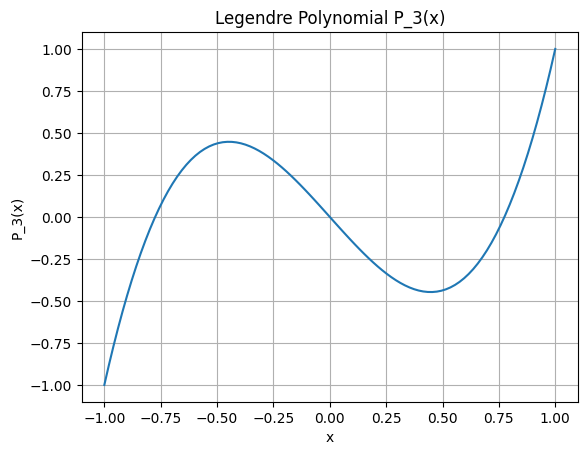

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pylab as plb
import math
from scipy.special import eval_legendre # Corrected import


A=[]
x_values = np.linspace(-1, 1, 100) # Use appropriate range for Legendre polynomial argument
for x in x_values:
  A.append(eval_legendre(3, x)) # Evaluate for each x value


plt.plot(x_values, A) # Plot against x_values
plt.xlabel('x')
plt.ylabel('P_3(x)')
plt.title('Legendre Polynomial P_3(x)')
plt.grid(True)
plt.show()